In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_parquet("history.parquet")

# Remove all rows for Mogadishu
df = df[df['capital'] != 'Mogadishu']

# Add season column based on month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

def get_decade(year):
    if 1995 <= year <= 2004:
        return '1995-2004'
    elif 2005 <= year <= 2014:
        return '2005-2014'
    elif 2015 <= year <= 2024:
        return '2015-2024'
    else:
        return 'Unknown'
    
def get_triennio(year):
    if 1995 <= year <= 1997:
        return '1995-1997'
    elif 1998 <= year <= 2000:
        return '1998-2000'
    elif 2001 <= year <= 2003:
        return '2001-2003'
    elif 2004 <= year <= 2006:
        return '2004-2006'
    elif 2007 <= year <= 2009:
        return '2007-2009'
    elif 2010 <= year <= 2012:
        return '2010-2012'
    elif 2013 <= year <= 2015:
        return '2013-2015'
    elif 2016 <= year <= 2018:
        return '2016-2018'
    elif 2019 <= year <= 2021:
        return '2019-2021'
    elif 2022 <= year <= 2024:
        return '2022-2024'
    else:
        return 'Unknown'
    
def get_group(year):
    if year <= 2009:
        return 1
    else:
        return 2



df['date'] = pd.to_datetime(df['date'])

df['season'] = df['date'].dt.month.apply(get_season)
df['temp_variation'] = df['temp_max_c'] - df['temp_min_c']
df['year'] = df['date'].dt.year
df['decade'] = df['year'].apply(get_decade)
df['group'] = df['year'].apply(get_group)
df['triennio'] = df['year'].apply(get_triennio)

#We'll need it later
capital_to_country = df[['capital', 'country']].drop_duplicates().set_index('capital')['country'].to_dict()
#Columns to drop

columns_to_keep = ['temp_mean_c_approx', 'rain_mm', 'snow_mm', 'windspeed_10m_max_kmh', 'temp_variation', 'sunshine_duration_s', 'daylight_duration_s', 'capital', 'year', 'season', 'date', 'decade', 'group', 'triennio']
df = df[columns_to_keep]

In [4]:
aggregation_per_triennio = df.groupby(['capital','triennio']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

aggregation_per_season_triennio = df.groupby(['capital', 'season', 'triennio']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()


In [10]:
import plotly.graph_objects as go
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Lista di tutti i trienni
trienni = ['1995-1997', '1998-2000', '2001-2003', '2004-2006', '2007-2009',
           '2010-2012', '2013-2015', '2016-2018', '2019-2021', '2022-2024']

# Dizionario per salvare i risultati
df_clusters_trienni = {}
cluster_means_trienni = {}

# Features da utilizzare
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine']

# Numero di cluster
k = 5

# Ciclo su ogni triennio
for triennio in trienni:
    print(f"\n{'='*80}")
    print(f"CLUSTERING PER TRIENNIO: {triennio}")
    print(f"{'='*80}")
    
    # Filtra i dati per il triennio corrente
    df_triennio = aggregation_per_triennio[aggregation_per_triennio['triennio'] == triennio].copy()
    
    # Prepara i dati
    X = df_triennio[features].copy()
    X["rain_total"] = np.log1p(X["rain_total"])
    X["snow_total"] = np.log1p(X["snow_total"])
    
    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # K-Means clustering
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    df_triennio["cluster"] = kmeans.fit_predict(X_scaled)
        
    # Aggiungi country
    df_triennio['country'] = df_triennio['capital'].map(capital_to_country)
    
    # Salva il dataframe
    df_clusters_trienni[triennio] = df_triennio
    
    # Calcola le medie per cluster
    cluster_means = df_triennio.groupby('cluster')[features].mean()
    cluster_means_display = cluster_means.copy()
    #cluster_means_display['rain_total'] = np.expm1(cluster_means_display['rain_total'])
    #cluster_means_display['snow_total'] = np.expm1(cluster_means_display['snow_total'])
    
    cluster_means_trienni[triennio] = cluster_means_display
    
    # Stampa distribuzione cluster
    print(f"\nDistribuzione cluster:")
    print(df_triennio['cluster'].value_counts().sort_index())
    print(f"\nMedie per cluster:")
    print(cluster_means_display)

print(f"\n{'='*80}")
print("CLUSTERING COMPLETATO PER TUTTI I TRIENNI")
print(f"{'='*80}")


CLUSTERING PER TRIENNIO: 1995-1997

Distribuzione cluster:
cluster
0    24
1    35
2    27
3    63
4    14
Name: count, dtype: int64

Medie per cluster:
         mean_temp  std_temp   rain_total   days_rain  snow_total   days_snow  \
cluster                                                                         
0        23.475431  1.118072  8106.462500  828.541667   14.043750    2.583333   
1        10.437336  8.195637  2077.905714  299.400000  151.542000   37.685714   
2        22.075747  5.625258   850.385185  128.333333    1.897778    0.629630   
3        23.467962  2.178428  3546.853968  450.777778    0.080000    0.015873   
4         5.322289  9.127506  1845.142857  304.571429  414.700000  109.142857   

         mean_daylight  mean_sunshine  
cluster                                
0         43632.536897   33956.708740  
1         44032.655032   30484.197943  
2         43753.675158   38356.732392  
3         43660.259143   36311.974454  
4         44423.978235   25584.756931 

ora mi fai un remapping dei clustering. ti diro per ogni triennio come rimappare. se non specifcio il triennio non rimappare. se per un triennio non specifico l'indice, quell'indice rimane dove sta. origine->dest è la sintassi.

1998-2000:
- 0->4
- 1->3
- 2->1
- 3->0
- 4->2

2001-2003:
- 0->4
- 1->0
- 2->2
- 3->1
- 4->3

2004-2006:
- 0->0
- 1->1
- 2->3
- 3->4
- 4->2

2007-2009:
- 0->4
- 1->0
- 2->1
- 3->3
- 4->2

2010-2012:
- 2-> 4
- 3->2
- 4->3

2013-2015
- 0->2
- 1->4
- 2->3
- 3->0
- 4->1

2016-2018
- 0->2
- 1->4
- 2->0
- 3->1
- 4->3

2019-2021
- 0->2
- 1->4
- 2->3
- 3->1
- 4->0

2022-2024
- 4->4
- 1->1
- 2->3
- 0->2
- 3->0

In [11]:
# Definisci le mappature per ogni triennio
cluster_remappings = {
    '1998-2000': {0: 4, 1: 3, 2: 1, 3: 0, 4: 2},
    '2001-2003': {0: 4, 1: 0, 2: 2, 3: 1, 4: 3},
    '2004-2006': {0: 0, 1: 1, 2: 3, 3: 4, 4: 2},
    '2007-2009': {0: 4, 1: 0, 2: 1, 3: 3, 4: 2},
    '2010-2012': {0: 0, 1: 1, 2: 4, 3: 2, 4: 3},  # Solo 2, 3, 4 specificati, altri rimangono
    '2013-2015': {0: 2, 1: 4, 2: 3, 3: 0, 4: 1},
    '2016-2018': {0: 2, 1: 4, 2: 0, 3: 1, 4: 3},
    '2019-2021': {0: 2, 1: 4, 2: 3, 3: 1, 4: 0},
    '2022-2024': {0: 2, 1: 1, 2: 3, 3: 0, 4: 4}
}

# Applica le mappature ai dataframe dei trienni
print("="*80)
print("REMAPPING DEI CLUSTER PER TRIENNIO")
print("="*80)

for triennio in trienni:
    if triennio in cluster_remappings:
        print(f"\nRemapping {triennio}: {cluster_remappings[triennio]}")
        df_clusters_trienni[triennio]['cluster'] = df_clusters_trienni[triennio]['cluster'].map(cluster_remappings[triennio])
        
        # Ricalcola le medie dopo il remapping
        cluster_means = df_clusters_trienni[triennio].groupby('cluster')[features].mean()
        cluster_means_display = cluster_means.copy()
        #cluster_means_display['rain_total'] = np.expm1(cluster_means_display['rain_total'])
        #cluster_means_display['snow_total'] = np.expm1(cluster_means_display['snow_total'])
        
        cluster_means_trienni[triennio] = cluster_means_display
        
        print(f"Nuova distribuzione cluster:")
        print(df_clusters_trienni[triennio]['cluster'].value_counts().sort_index())
    else:
        print(f"\n{triennio}: Nessun remapping specificato, cluster invariati")

print("\n" + "="*80)
print("REMAPPING COMPLETATO")
print("="*80)

REMAPPING DEI CLUSTER PER TRIENNIO

1995-1997: Nessun remapping specificato, cluster invariati

Remapping 1998-2000: {0: 4, 1: 3, 2: 1, 3: 0, 4: 2}
Nuova distribuzione cluster:
cluster
0    24
1    36
2    28
3    60
4    15
Name: count, dtype: int64

Remapping 2001-2003: {0: 4, 1: 0, 2: 2, 3: 1, 4: 3}
Nuova distribuzione cluster:
cluster
0    49
1    35
2    14
3    50
4    15
Name: count, dtype: int64

Remapping 2004-2006: {0: 0, 1: 1, 2: 3, 3: 4, 4: 2}
Nuova distribuzione cluster:
cluster
0    28
1    35
2    30
3    54
4    16
Name: count, dtype: int64

Remapping 2007-2009: {0: 4, 1: 0, 2: 1, 3: 3, 4: 2}
Nuova distribuzione cluster:
cluster
0    24
1    35
2    36
3    55
4    13
Name: count, dtype: int64

Remapping 2010-2012: {0: 0, 1: 1, 2: 4, 3: 2, 4: 3}
Nuova distribuzione cluster:
cluster
0    23
1    37
2    34
3    57
4    12
Name: count, dtype: int64

Remapping 2013-2015: {0: 2, 1: 4, 2: 3, 3: 0, 4: 1}
Nuova distribuzione cluster:
cluster
0    29
1    33
2    36
3    51
4  

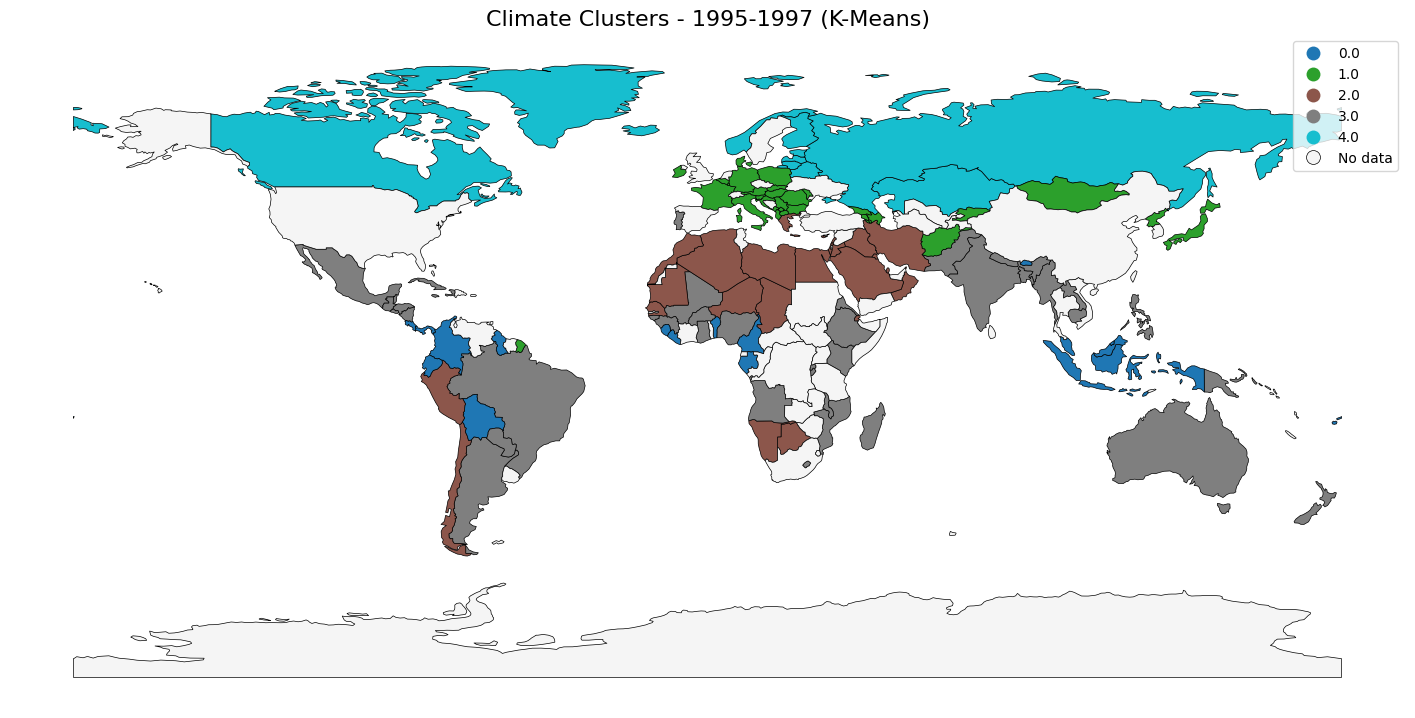

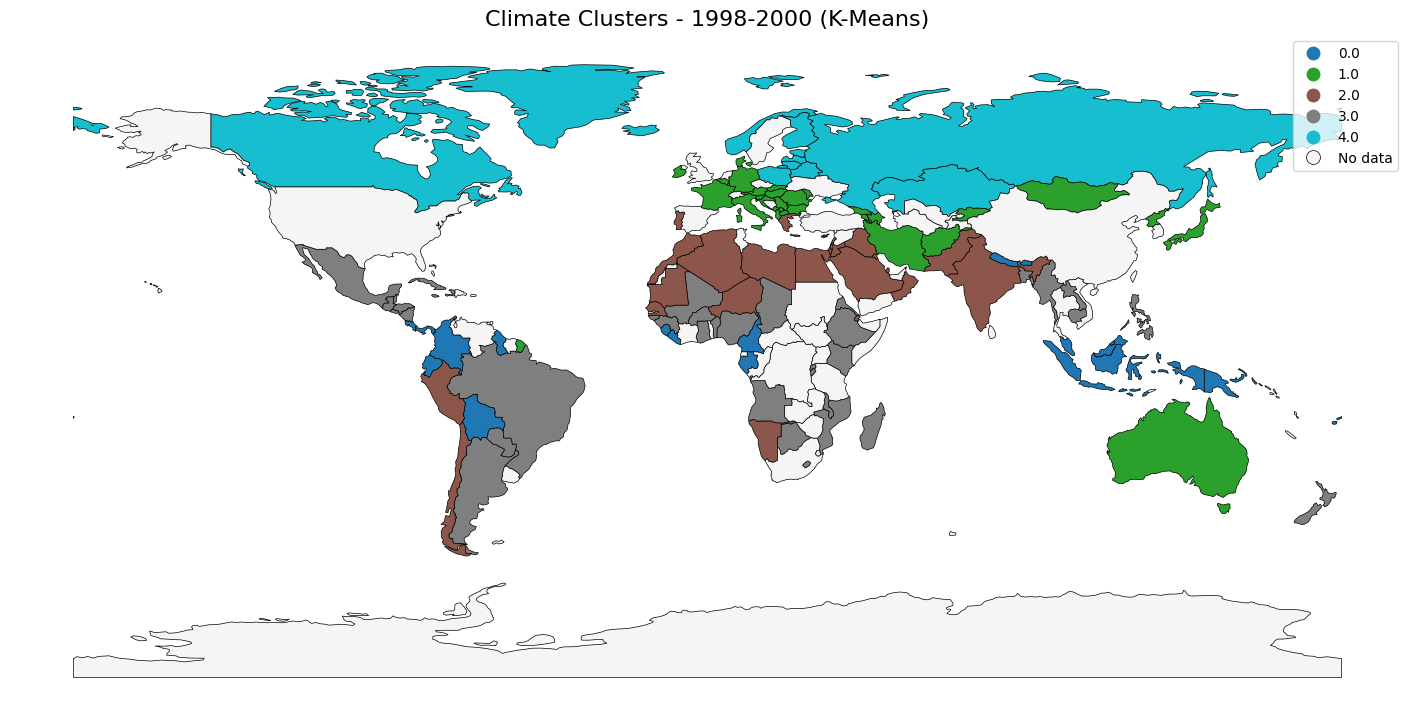

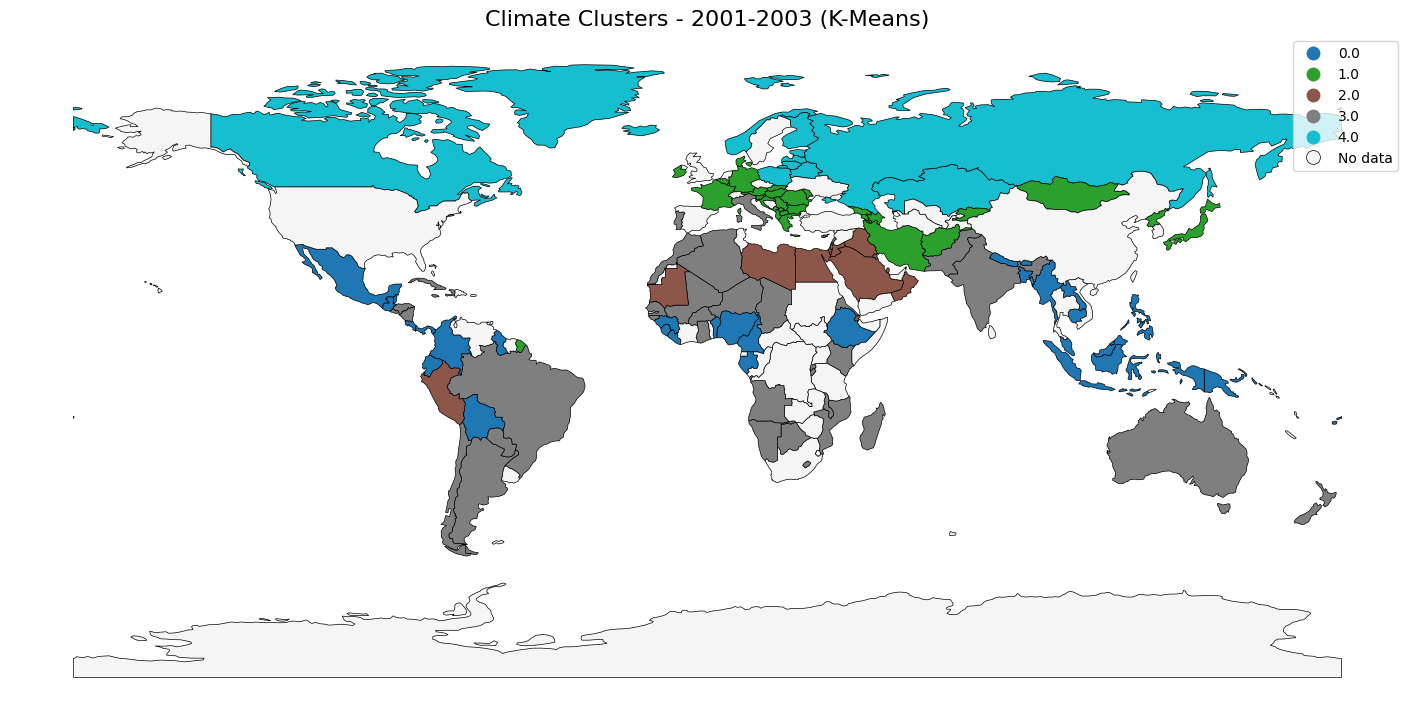

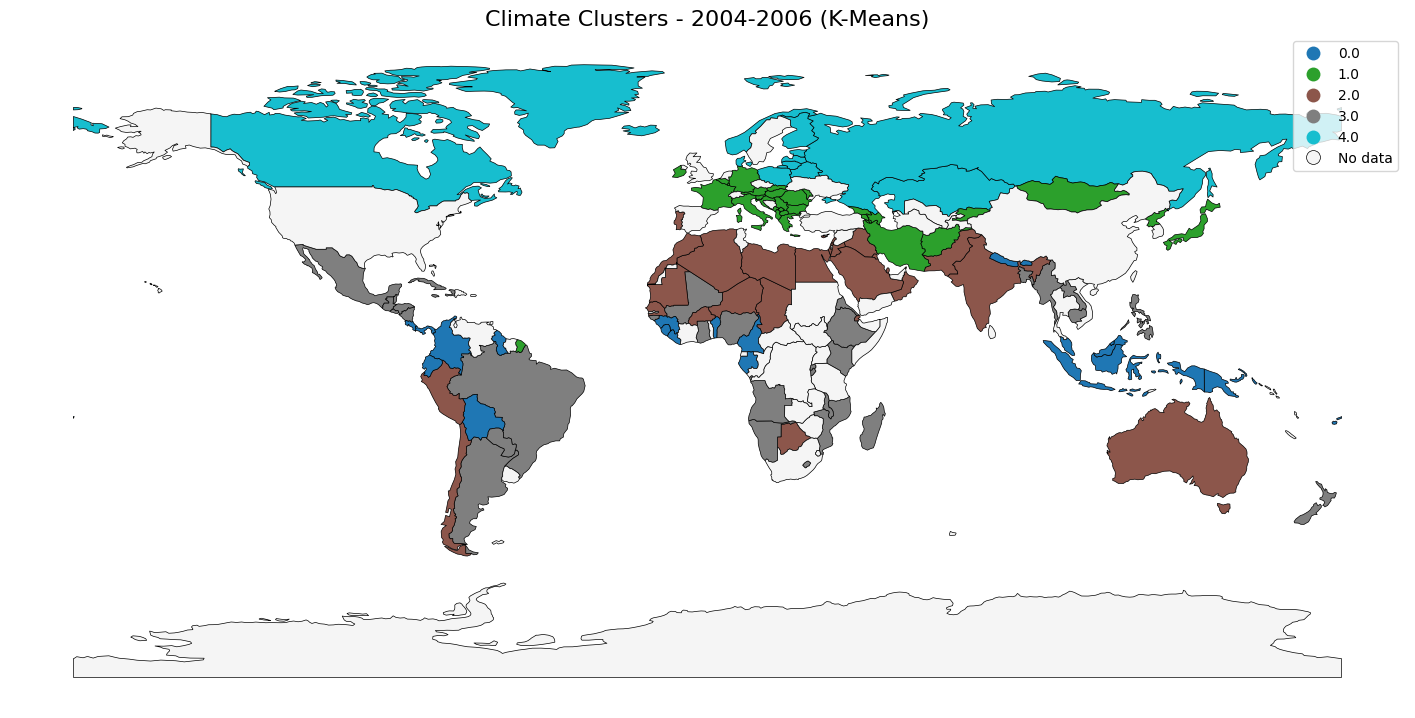

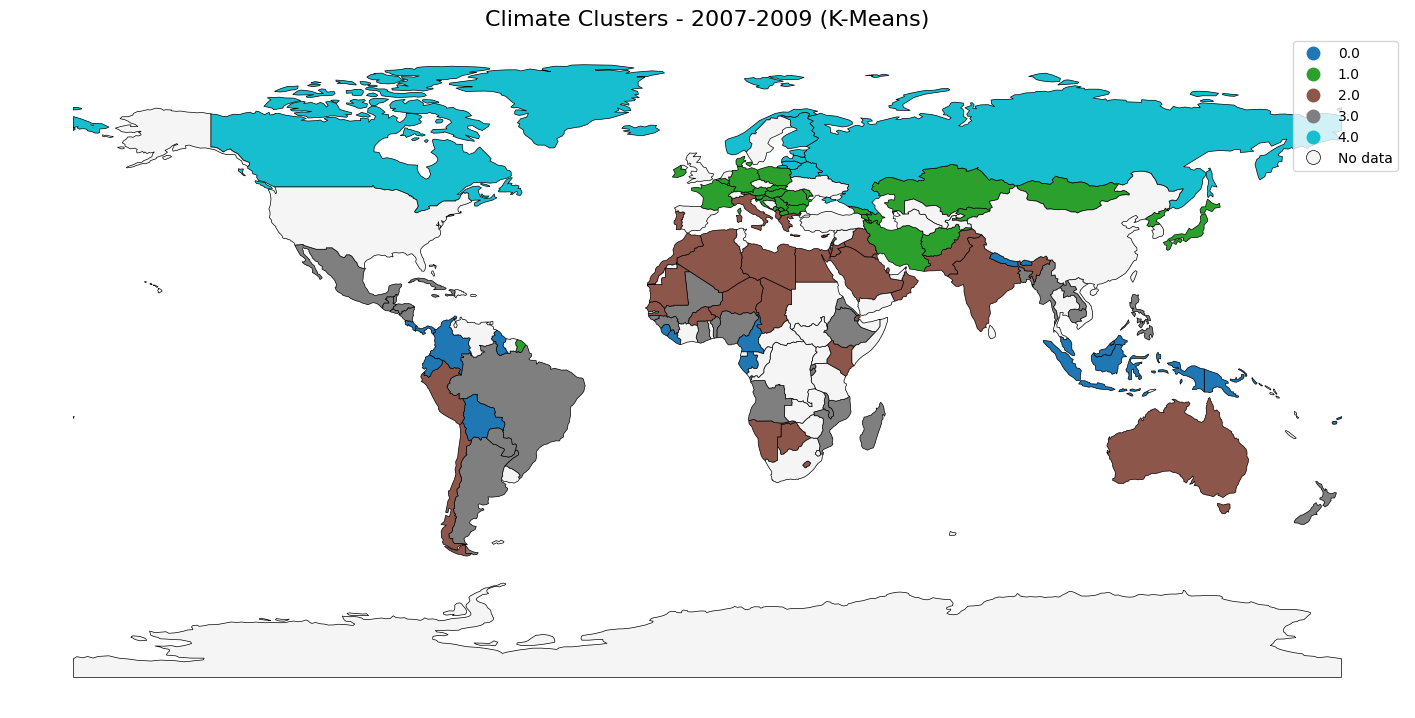

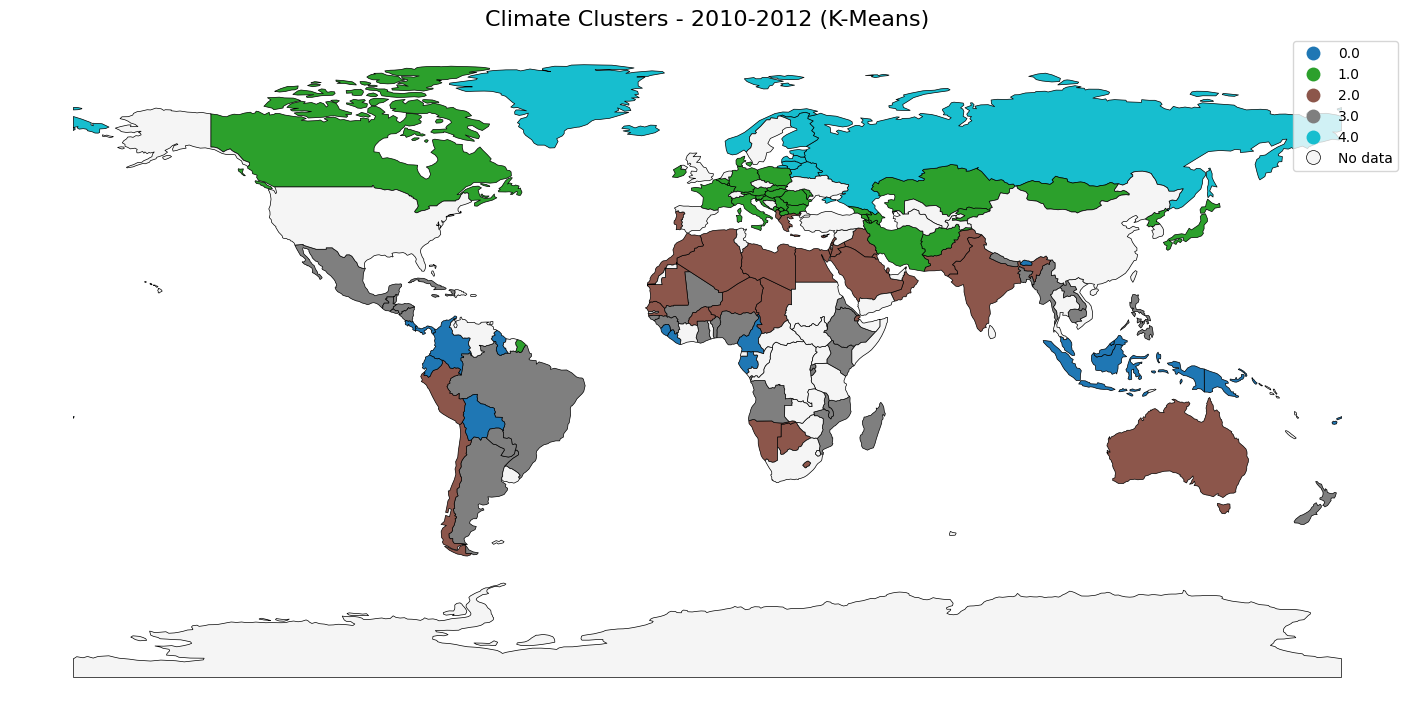

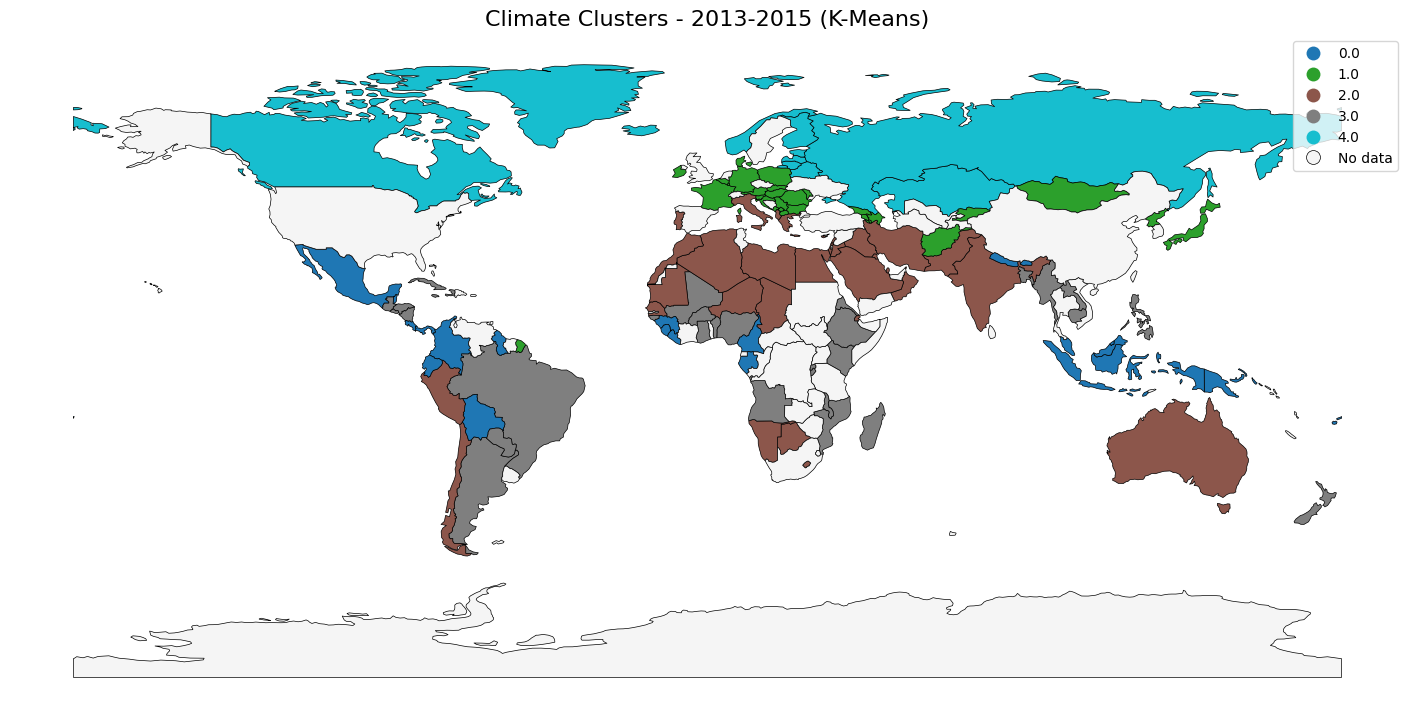

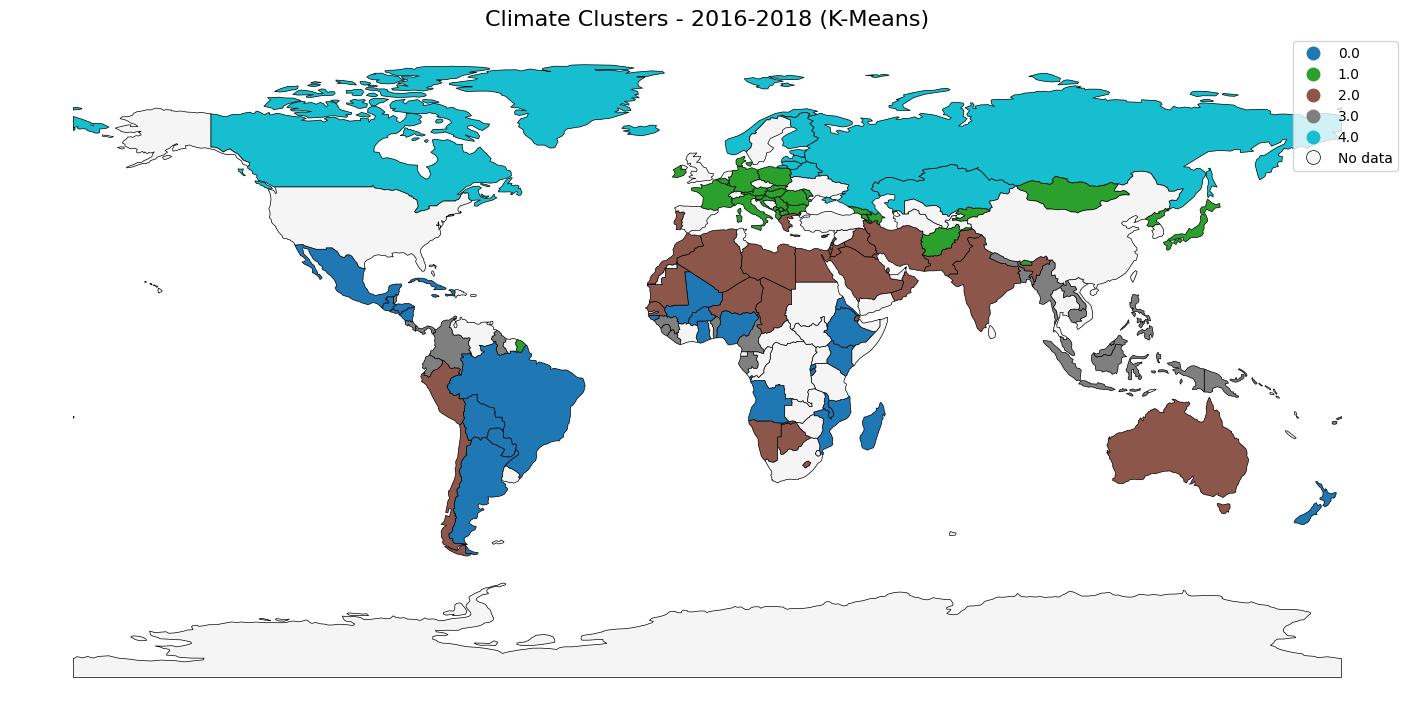

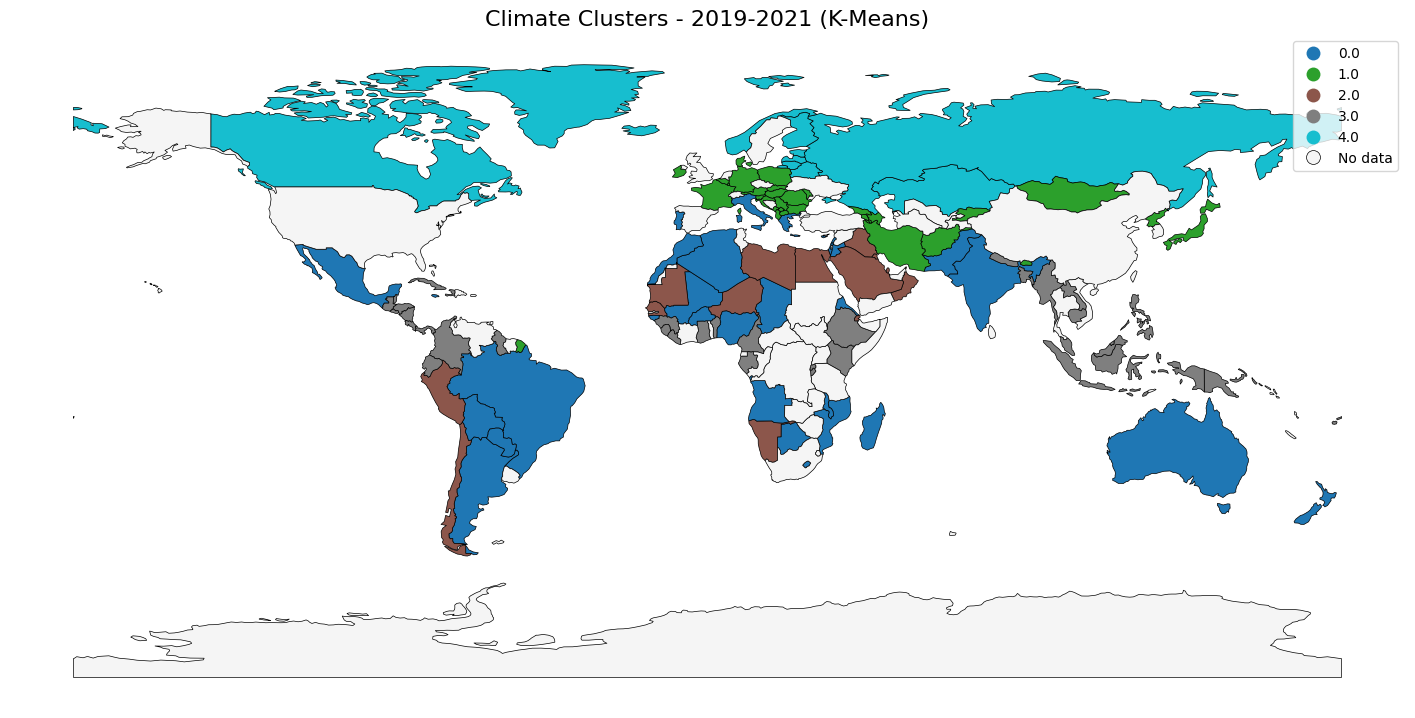

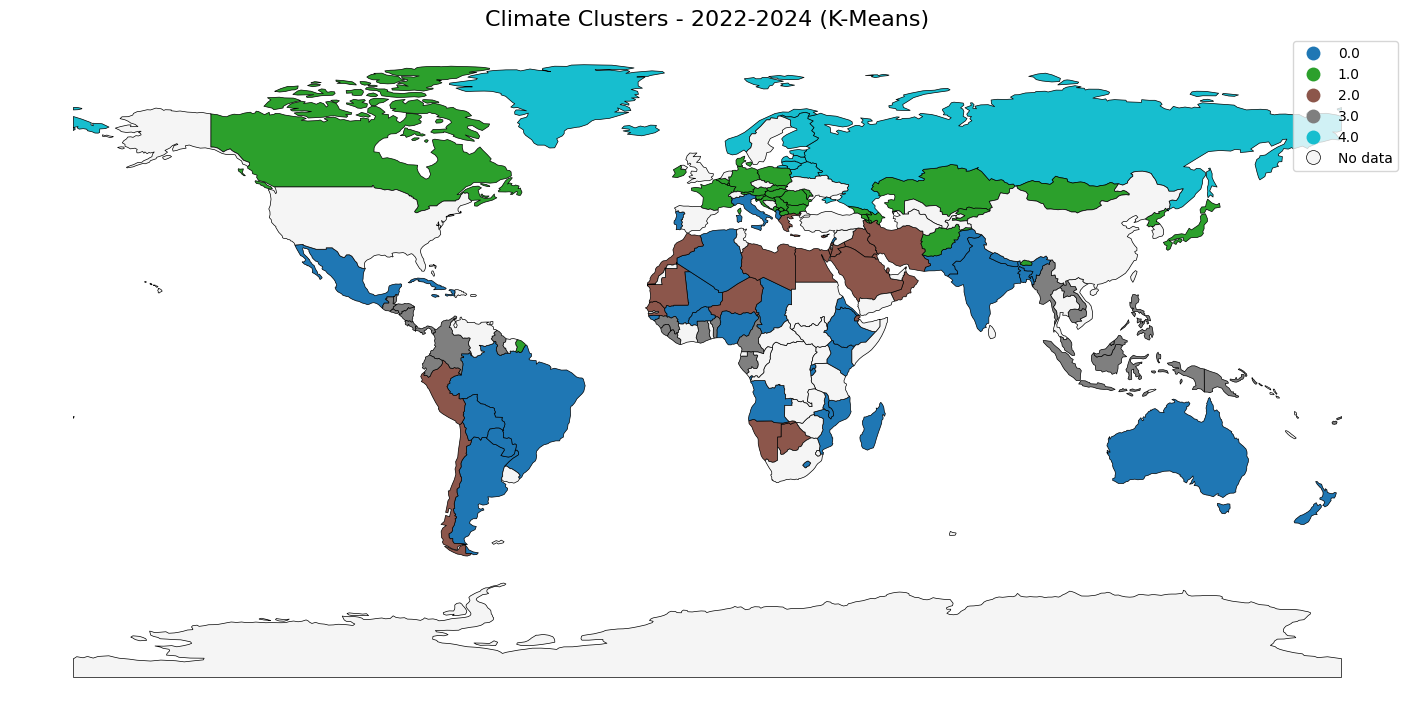

In [12]:
def plot_world_triennio(df_cluster_assignment, triennio, method="K-Means"):
    """
    Visualizza la mappa mondiale per un triennio specifico
    """
    import geopandas as gpd
    
    # World map data
    world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(world_url)
    
    # Merge data
    world_clusters = world.merge(
        df_cluster_assignment,
        how="left",
        left_on="NAME",
        right_on="country"
    )
    
    fig, ax = plt.subplots(1, 1, figsize=(18, 9))
    
    world_clusters.plot(
        column="cluster",
        categorical=True,
        cmap="tab10",
        linewidth=0.5,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={
            "color": "whitesmoke",
            "label": "No data"
        }
    )
    
    ax.set_title(
        f"Climate Clusters - {triennio} ({method})",
        fontsize=16
    )
    
    ax.axis("off")
    plt.show()

# Visualizza le mappe per tutti i trienni
for triennio in trienni:
    plot_world_triennio(df_clusters_trienni[triennio], triennio)


EVOLUZIONE TEMPERATURE MEDIE PER CLUSTER NEI TRIENNI (DOPO REMAPPING)
         1995-1997  1998-2000  2001-2003  2004-2006  2007-2009  2010-2012  \
cluster                                                                     
0        23.475431  23.115574  24.205955  23.781136  23.131594  23.440336   
1        10.437336  11.502719  11.476532  11.496053  11.248260  10.855901   
2        22.075747  22.113148  23.985421  22.446615  21.561053  21.921947   
3        23.467962  24.189678  22.440235  23.944533  24.405197  24.303726   
4         5.322289   6.067220   6.152289   6.315793   6.407422   5.930737   

         2013-2015  2016-2018  2019-2021  2022-2024  
cluster                                              
0        23.512256  23.964889  21.062446  21.599777  
1        11.470325  11.988523  12.188607  12.045751  
2        21.585185  22.102755  24.901075  23.264753  
3        24.558867  25.170635  25.147226  25.837810  
4         6.420936   6.104506   7.216241   6.639030  


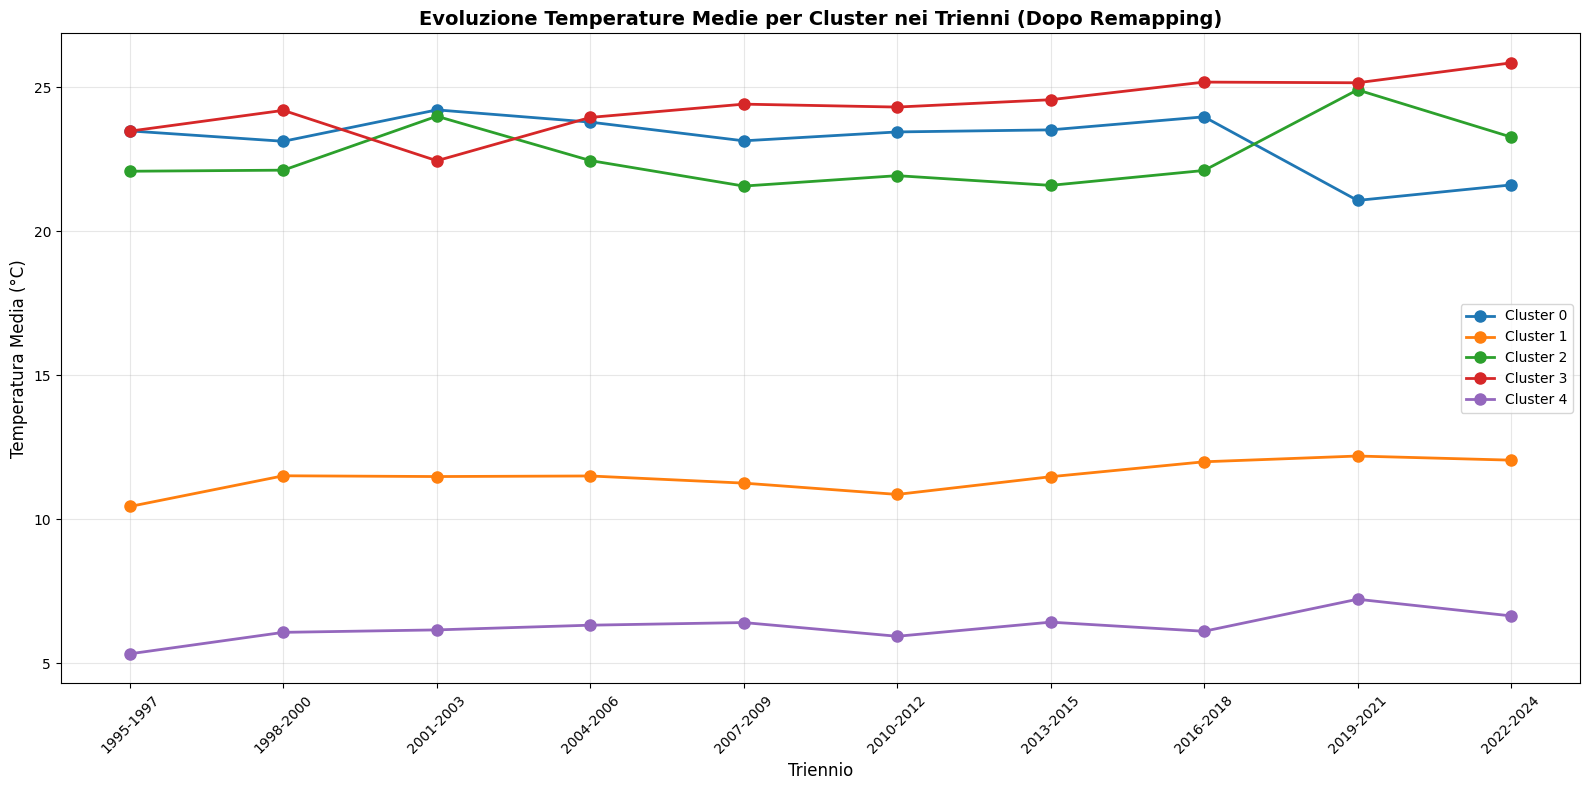


EVOLUZIONE PRECIPITAZIONI TOTALI PER CLUSTER NEI TRIENNI (DOPO REMAPPING)
           1995-1997    1998-2000    2001-2003    2004-2006    2007-2009  \
cluster                                                                    
0        8106.462500  8337.475000  6307.918367  7687.096429  8600.400000   
1        2077.905714  2016.544444  2002.434286  1999.302857  2000.600000   
2         850.385185   846.403571   302.650000   913.440000  1081.061111   
3        3546.853968  3325.000000  2146.160000  3444.411111  3561.520000   
4        1845.142857  1958.520000  1903.500000  1925.125000  2159.407692   

           2010-2012    2013-2015    2016-2018    2019-2021    2022-2024  
cluster                                                                   
0        8757.982609  7807.948276  3311.528571  2208.517949  2961.939024  
1        1949.089189  2111.384848  2405.832432  2311.455882  2348.427778  
2        1191.173529  1079.022222  1044.433333   431.562500   738.879167  
3        3755.550

In [13]:
# Mostra l'evoluzione delle temperature dopo il remapping
print("\n" + "="*100)
print("EVOLUZIONE TEMPERATURE MEDIE PER CLUSTER NEI TRIENNI (DOPO REMAPPING)")
print("="*100)

comparison_data_remapped = {}
for triennio in trienni:
    comparison_data_remapped[triennio] = cluster_means_trienni[triennio]['mean_temp']

comparison_temp_remapped = pd.DataFrame(comparison_data_remapped)
print(comparison_temp_remapped)

# Grafico evoluzione temperature dopo remapping
plt.figure(figsize=(16, 8))
for cluster_id in range(k):
    if cluster_id in comparison_temp_remapped.index:
        temps = comparison_temp_remapped.loc[cluster_id]
        plt.plot(trienni, temps, marker='o', label=f'Cluster {cluster_id}', linewidth=2, markersize=8)

plt.xlabel('Triennio', fontsize=12)
plt.ylabel('Temperatura Media (°C)', fontsize=12)
plt.title('Evoluzione Temperature Medie per Cluster nei Trienni (Dopo Remapping)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Mostra anche le precipitazioni
print("\n" + "="*100)
print("EVOLUZIONE PRECIPITAZIONI TOTALI PER CLUSTER NEI TRIENNI (DOPO REMAPPING)")
print("="*100)

comparison_rain_remapped = {}
for triennio in trienni:
    comparison_rain_remapped[triennio] = cluster_means_trienni[triennio]['rain_total']

comparison_rain_df = pd.DataFrame(comparison_rain_remapped)
print(comparison_rain_df)

In [14]:
def plot_cluster_flow_sankey(df_clusters_dict, trienni):
    """
    Crea un diagramma Sankey che mostra come le capitali si spostano tra cluster
    """
    import plotly.graph_objects as go
    
    # Analizza i flussi tra trienni consecutivi
    for i in range(len(trienni) - 1):
        t1 = trienni[i]
        t2 = trienni[i + 1]
        
        df1 = df_clusters_dict[t1][['capital', 'cluster']]
        df2 = df_clusters_dict[t2][['capital', 'cluster']]
        
        # Merge per trovare i movimenti
        flows = df1.merge(df2, on='capital', suffixes=('_from', '_to'))
        
        # Conta i flussi
        flow_counts = flows.groupby(['cluster_from', 'cluster_to']).size().reset_index(name='count')
        
        # Prepara i dati per Sankey
        sources = []
        targets = []
        values = []
        
        for _, row in flow_counts.iterrows():
            sources.append(int(row['cluster_from']))
            targets.append(int(row['cluster_to']) + k)  # Offset per distinguere
            values.append(row['count'])
        
        # Crea labels
        labels = [f"Cluster {i} ({t1})" for i in range(k)] + [f"Cluster {i} ({t2})" for i in range(k)]
        
        # Plot
        fig = go.Figure(data=[go.Sankey(
            node=dict(
                pad=15,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=labels
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values
            )
        )])
        
        fig.update_layout(
            title_text=f"Flusso di Capitali tra Cluster: {t1} → {t2}",
            font_size=12,
            height=600
        )
        fig.show()

plot_cluster_flow_sankey(df_clusters_trienni, trienni)

In [15]:
def plot_cluster_flow_sankey_first_to_last(df_clusters_dict, trienni):
    """
    Crea un diagramma Sankey che mostra come le capitali si spostano tra cluster
    dal primo all'ultimo triennio
    """
    import plotly.graph_objects as go
    
    first_triennio = trienni[0]
    last_triennio = trienni[-1]
    
    print(f"Creazione Sankey: {first_triennio} → {last_triennio}")
    
    df1 = df_clusters_dict[first_triennio][['capital', 'cluster']]
    df2 = df_clusters_dict[last_triennio][['capital', 'cluster']]
    
    # Merge per trovare i movimenti
    flows = df1.merge(df2, on='capital', suffixes=('_from', '_to'))
    
    # Conta i flussi
    flow_counts = flows.groupby(['cluster_from', 'cluster_to']).size().reset_index(name='count')
    
    # Stampa statistiche
    print(f"\nStatistiche dei flussi:")
    print(f"Totale capitali tracciate: {len(flows)}")
    print(f"\nMatrice di transizione:")
    transition_matrix = flows.groupby(['cluster_from', 'cluster_to']).size().unstack(fill_value=0)
    print(transition_matrix)
    
    # Calcola stabilità per cluster
    print(f"\nStabilità per cluster (% che rimangono nello stesso cluster):")
    for cluster_id in range(k):
        same_cluster = len(flows[(flows['cluster_from'] == cluster_id) & (flows['cluster_to'] == cluster_id)])
        total_in_cluster = len(flows[flows['cluster_from'] == cluster_id])
        if total_in_cluster > 0:
            stability = (same_cluster / total_in_cluster) * 100
            print(f"  Cluster {cluster_id}: {stability:.1f}% ({same_cluster}/{total_in_cluster})")
    
    # Prepara i dati per Sankey
    sources = []
    targets = []
    values = []
    colors = []
    
    # Colori per i link
    link_colors = {
        'stable': 'rgba(0, 128, 0, 0.4)',      # Verde per chi rimane
        'change': 'rgba(255, 165, 0, 0.3)'     # Arancione per chi cambia
    }
    
    for _, row in flow_counts.iterrows():
        sources.append(int(row['cluster_from']))
        targets.append(int(row['cluster_to']) + k)  # Offset per distinguere
        values.append(row['count'])
        
        # Colora diversamente chi rimane nello stesso cluster
        if row['cluster_from'] == row['cluster_to']:
            colors.append(link_colors['stable'])
        else:
            colors.append(link_colors['change'])
    
    # Crea labels
    labels = [f"Cluster {i}\n({first_triennio})" for i in range(k)] + \
             [f"Cluster {i}\n({last_triennio})" for i in range(k)]
    
    # Colori per i nodi
    node_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] * 2
    
    # Plot
    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=20,
            thickness=25,
            line=dict(color="black", width=1),
            label=labels,
            color=node_colors
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors
        )
    )])
    
    fig.update_layout(
        title_text=f"Flusso di Capitali tra Cluster: {first_triennio} → {last_triennio}<br>" +
                   f"<sub>Verde = rimane nello stesso cluster | Arancione = cambia cluster</sub>",
        font_size=14,
        height=700,
        width=1200
    )
    
    fig.show()
    
    return flows

# Crea il diagramma e salva i flussi
flows_first_last = plot_cluster_flow_sankey_first_to_last(df_clusters_trienni, trienni)

Creazione Sankey: 1995-1997 → 2022-2024

Statistiche dei flussi:
Totale capitali tracciate: 163

Matrice di transizione:
cluster_to     0   1   2   3   4
cluster_from                    
0              1   1   0  22   0
1              3  32   0   0   0
2              3   0  24   0   0
3             34   0   0  29   0
4              0   3   0   0  11

Stabilità per cluster (% che rimangono nello stesso cluster):
  Cluster 0: 4.2% (1/24)
  Cluster 1: 91.4% (32/35)
  Cluster 2: 88.9% (24/27)
  Cluster 3: 46.0% (29/63)
  Cluster 4: 78.6% (11/14)


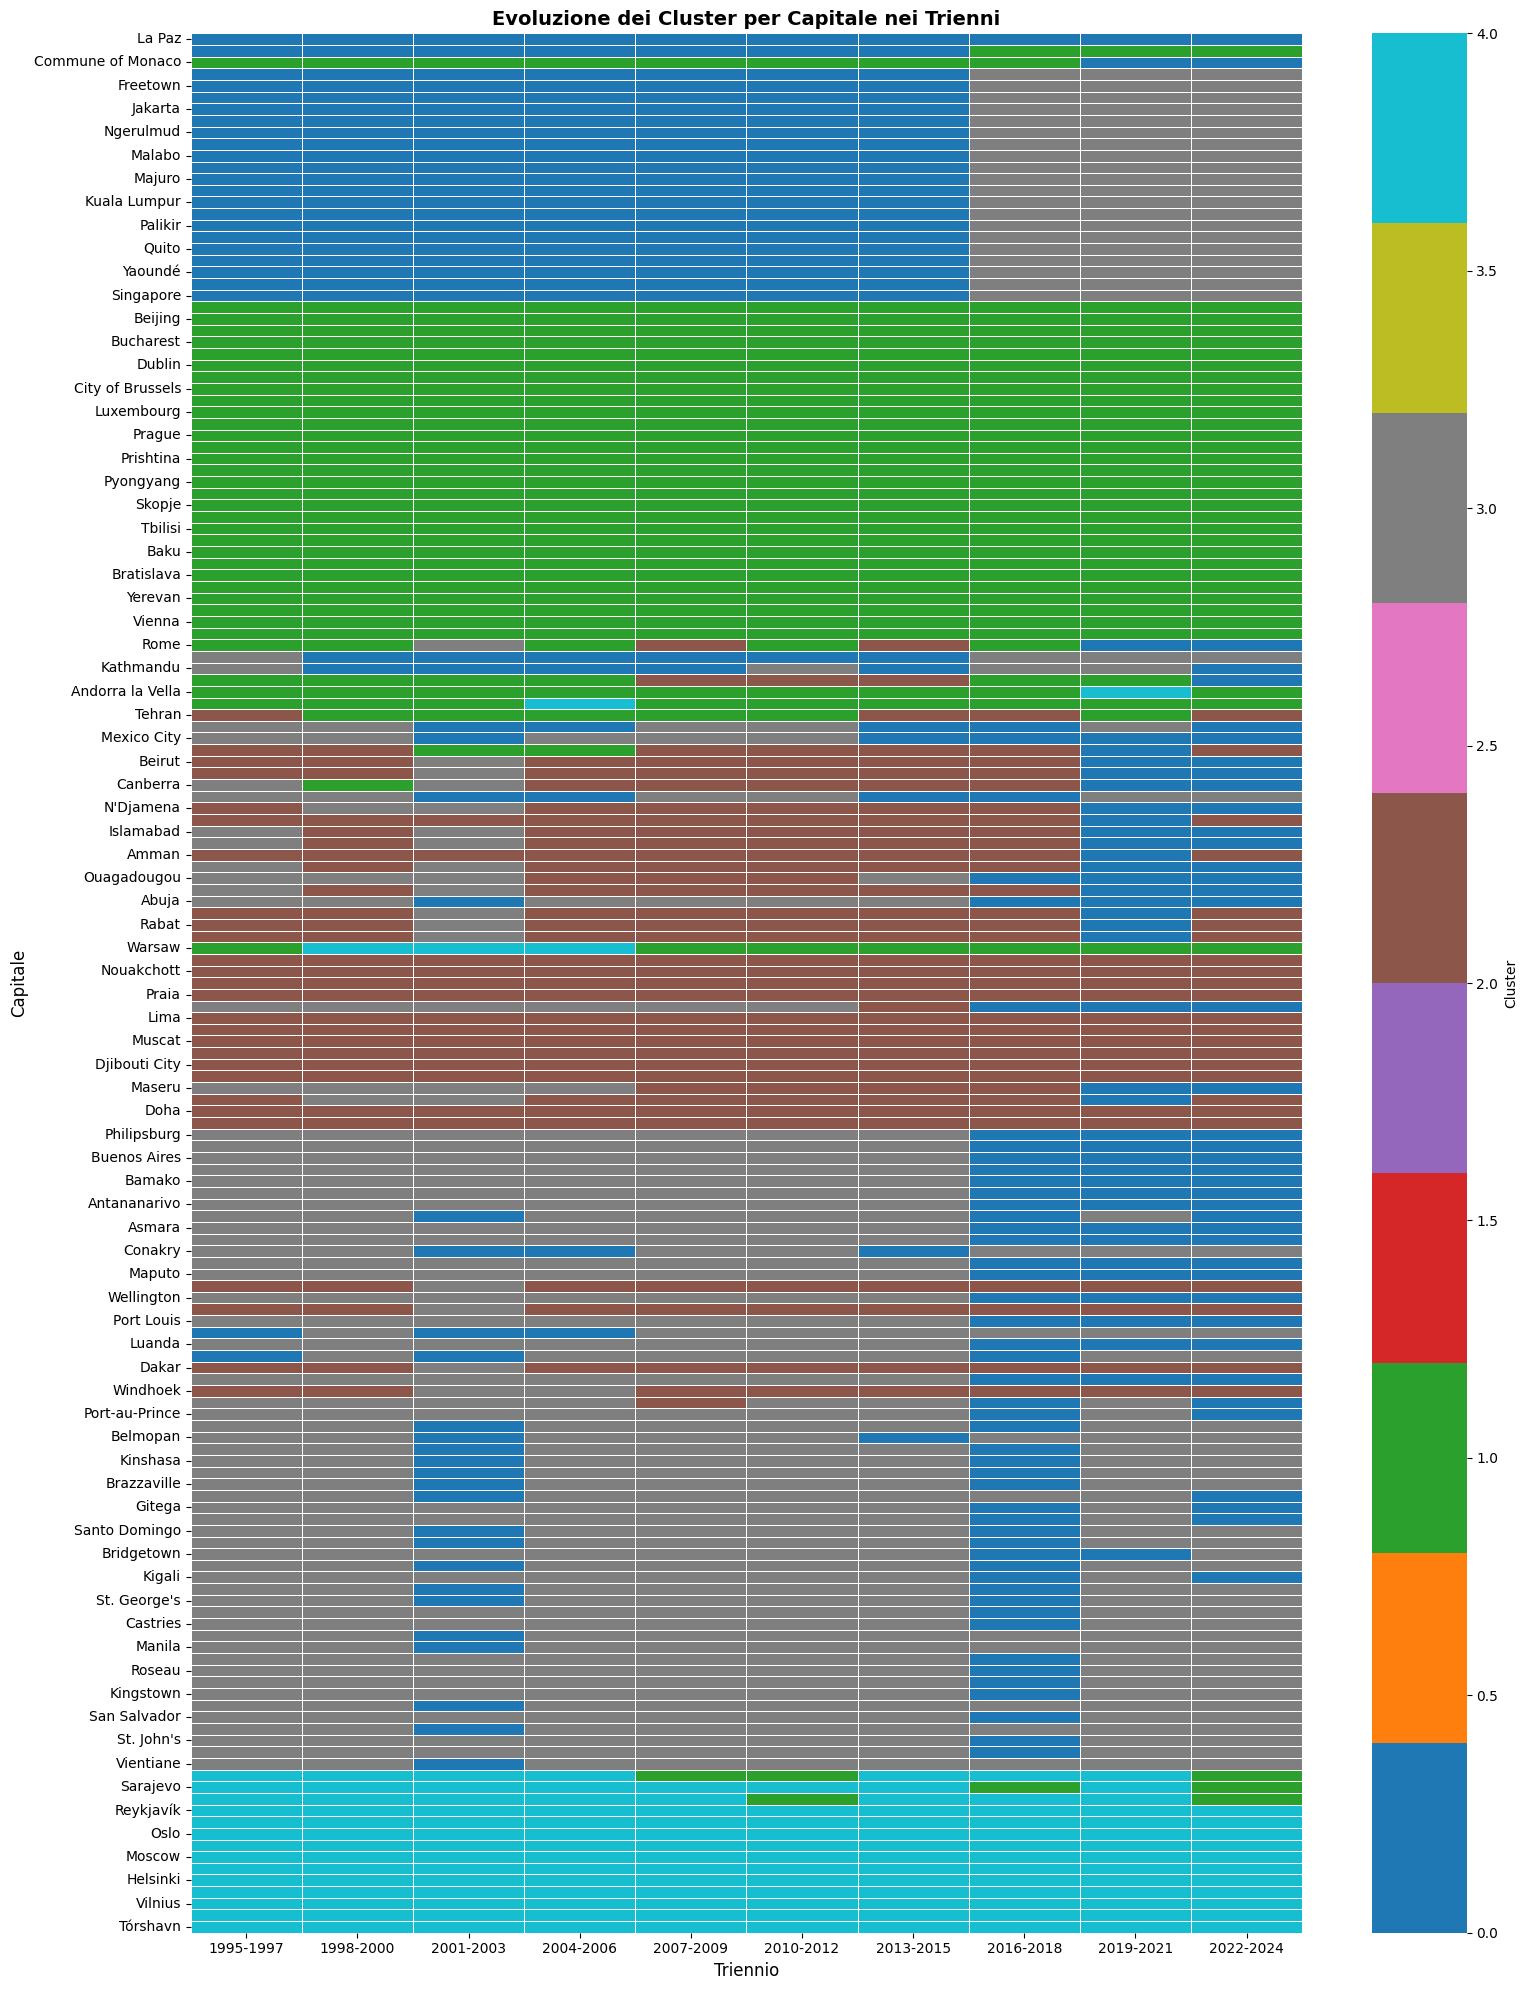

In [16]:
def plot_cluster_evolution_heatmap(df_clusters_dict, trienni):
    """
    Crea una heatmap che mostra l'evoluzione dei cluster per ogni capitale
    """
    import seaborn as sns
    
    # Crea una matrice capitale x triennio
    all_capitals = df_clusters_dict[trienni[0]]['capital'].unique()
    
    cluster_evolution = pd.DataFrame(index=all_capitals, columns=trienni)
    
    for triennio in trienni:
        df = df_clusters_dict[triennio]
        for capital in all_capitals:
            capital_data = df[df['capital'] == capital]
            if not capital_data.empty:
                cluster_evolution.loc[capital, triennio] = capital_data['cluster'].values[0]
    
    # Converti in numerico
    cluster_evolution = cluster_evolution.astype(float)
    
    # Ordina per cluster medio
    cluster_evolution['mean_cluster'] = cluster_evolution.mean(axis=1)
    cluster_evolution = cluster_evolution.sort_values('mean_cluster')
    cluster_evolution = cluster_evolution.drop('mean_cluster', axis=1)
    
    # Plot
    plt.figure(figsize=(16, 20))
    sns.heatmap(cluster_evolution, annot=False, cmap='tab10', cbar_kws={'label': 'Cluster'}, 
                linewidths=0.5, vmin=0, vmax=4)
    plt.title('Evoluzione dei Cluster per Capitale nei Trienni', fontsize=14, fontweight='bold')
    plt.xlabel('Triennio', fontsize=12)
    plt.ylabel('Capitale', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_cluster_evolution_heatmap(df_clusters_trienni, trienni)

In [17]:
def track_cluster_composition(df_clusters_dict, trienni, reference_capitals=['Rome', 'London', 'Moscow', 'Cairo', 'Tokyo']):
    """
    Traccia la composizione dei cluster seguendo un set di capitali di riferimento
    """
    print("="*80)
    print("TRACKING COMPOSIZIONE CLUSTER")
    print("="*80)
    
    for triennio in trienni:
        print(f"\n{triennio}:")
        df = df_clusters_dict[triennio]
        
        for capital in reference_capitals:
            capital_data = df[df['capital'] == capital]
            if not capital_data.empty:
                cluster_id = capital_data['cluster'].values[0]
                cluster_size = len(df[df['cluster'] == cluster_id])
                print(f"  {capital}: Cluster {cluster_id} ({cluster_size} capitali)")

track_cluster_composition(df_clusters_trienni, trienni)

TRACKING COMPOSIZIONE CLUSTER

1995-1997:
  Rome: Cluster 1 (35 capitali)
  Moscow: Cluster 4 (14 capitali)
  Cairo: Cluster 2 (27 capitali)
  Tokyo: Cluster 1 (35 capitali)

1998-2000:
  Rome: Cluster 1 (36 capitali)
  Moscow: Cluster 4 (15 capitali)
  Cairo: Cluster 2 (28 capitali)
  Tokyo: Cluster 1 (36 capitali)

2001-2003:
  Rome: Cluster 3 (50 capitali)
  Moscow: Cluster 4 (15 capitali)
  Cairo: Cluster 2 (14 capitali)
  Tokyo: Cluster 1 (35 capitali)

2004-2006:
  Rome: Cluster 1 (35 capitali)
  Moscow: Cluster 4 (16 capitali)
  Cairo: Cluster 2 (30 capitali)
  Tokyo: Cluster 1 (35 capitali)

2007-2009:
  Rome: Cluster 2 (36 capitali)
  Moscow: Cluster 4 (13 capitali)
  Cairo: Cluster 2 (36 capitali)
  Tokyo: Cluster 1 (35 capitali)

2010-2012:
  Rome: Cluster 1 (37 capitali)
  Moscow: Cluster 4 (12 capitali)
  Cairo: Cluster 2 (34 capitali)
  Tokyo: Cluster 1 (37 capitali)

2013-2015:
  Rome: Cluster 2 (36 capitali)
  Moscow: Cluster 4 (14 capitali)
  Cairo: Cluster 2 (36 capit